<a href="https://colab.research.google.com/github/martinpa-spec/Proyecto-Integrador-Henry-M5/blob/developer/comprension_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# INSTANCIA DE EDA📑

### 1. Librerías y Carga de Datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('Base_de_datos.xlsx')

df.head()

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,...,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,...,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,...,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,...,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,2025-04-26 11:24:26,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,...,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1


### 2. Inspección Inicial y Unificación de Nulos

Convertimos todos las formas de describir al nulo como una sola, y corregimos los tipos de variables ademas de asegurarnos de que las variables de los montos sean las correctas

In [ ]:
# Ver tipos de datos y nulos
print(df.info())

# Unificar representaciones de nulos a NaN
df.replace(['N/A', '-', 'NaN', 'null', ''], np.nan, inplace=True)

# Ver cantidad total de nulos por columna
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   tipo_credito                   10763 non-null  int64         
 1   fecha_prestamo                 10763 non-null  datetime64[ns]
 2   capital_prestado               10763 non-null  float64       
 3   plazo_meses                    10763 non-null  int64         
 4   edad_cliente                   10763 non-null  int64         
 5   tipo_laboral                   10763 non-null  object        
 6   salario_cliente                10763 non-null  int64         
 7   total_otros_prestamos          10763 non-null  int64         
 8   cuota_pactada                  10763 non-null  int64         
 9   puntaje                        10763 non-null  float64       
 10  puntaje_datacredito            10757 non-null  float64       
 11  cant_creditosvi

,0
tipo_credito,0
fecha_prestamo,0
capital_prestado,0
plazo_meses,0
edad_cliente,0
tipo_laboral,0
salario_cliente,0
total_otros_prestamos,0
cuota_pactada,0
puntaje,0


In [ ]:
# 1. Convertir 'tipo_credito' a categórica/string (es una ID, no un valor cuantitativo)
df['tipo_credito'] = df['tipo_credito'].astype(str)

# 2. Asegurar que las variables financieras sean flotantes
cols_moneda = ['salario_cliente', 'total_otros_prestamos', 'cuota_pactada']
df[cols_moneda] = df[cols_moneda].astype(float)

# 3. Confirmar que los tipos hayan cambiado
df.dtypes

,0
tipo_credito,object
fecha_prestamo,datetime64[ns]
capital_prestado,float64
plazo_meses,int64
edad_cliente,int64
tipo_laboral,object
salario_cliente,float64
total_otros_prestamos,float64
cuota_pactada,float64
puntaje,float64


¿Hay nulos?
Sí, hay bastantes nulos en varias columnas:

puntaje_datacredito: 6 nulos.

saldo_mora y saldo_total: 156 nulos.

saldo_principal: 405 nulos.

saldo_mora_codeudor: 590 nulos.

promedio_ingresos_datacredito: 2,930 nulos (~27% de la base).

tendencia_ingresos: 2,932 nulos.

### 3. Análisis Exploratorio (EDA)

,count,mean,min,25%,50%,75%,max,std
fecha_prestamo,10763,2025-04-16 23:06:02.111121664,2024-11-26 09:17:04,2025-01-20 17:33:07.500000,2025-03-27 16:23:12,2025-06-16 13:27:58,2026-04-26 18:43:52,NaN
capital_prestado,10763.0,2434315.001319,360000.0,1224831.0,1921920.0,3084840.0,41444152.8,1909642.758997
plazo_meses,10763.0,10.575583,2.0,6.0,10.0,12.0,90.0,6.632082
edad_cliente,10763.0,43.94862,19.0,33.0,42.0,53.0,123.0,15.060877
salario_cliente,10763.0,17216431.459909,0.0,2000000.0,3000000.0,4875808.0,22000000000.0,355476717.603478
total_otros_prestamos,10763.0,6238869.648518,0.0,500000.0,1000000.0,2000000.0,6787675263.0,118418316.94107
cuota_pactada,10763.0,243617.406671,23944.0,121041.5,182863.0,287833.5,3816752.0,210493.694608
puntaje,10763.0,91.170036,-38.00999,95.227787,95.227787,95.227787,95.227787,16.465441
puntaje_datacredito,10757.0,780.790834,-7.0,757.0,791.0,825.0,999.0,104.878031
cant_creditosvigentes,10763.0,5.726749,0.0,3.0,5.0,8.0,62.0,3.977162


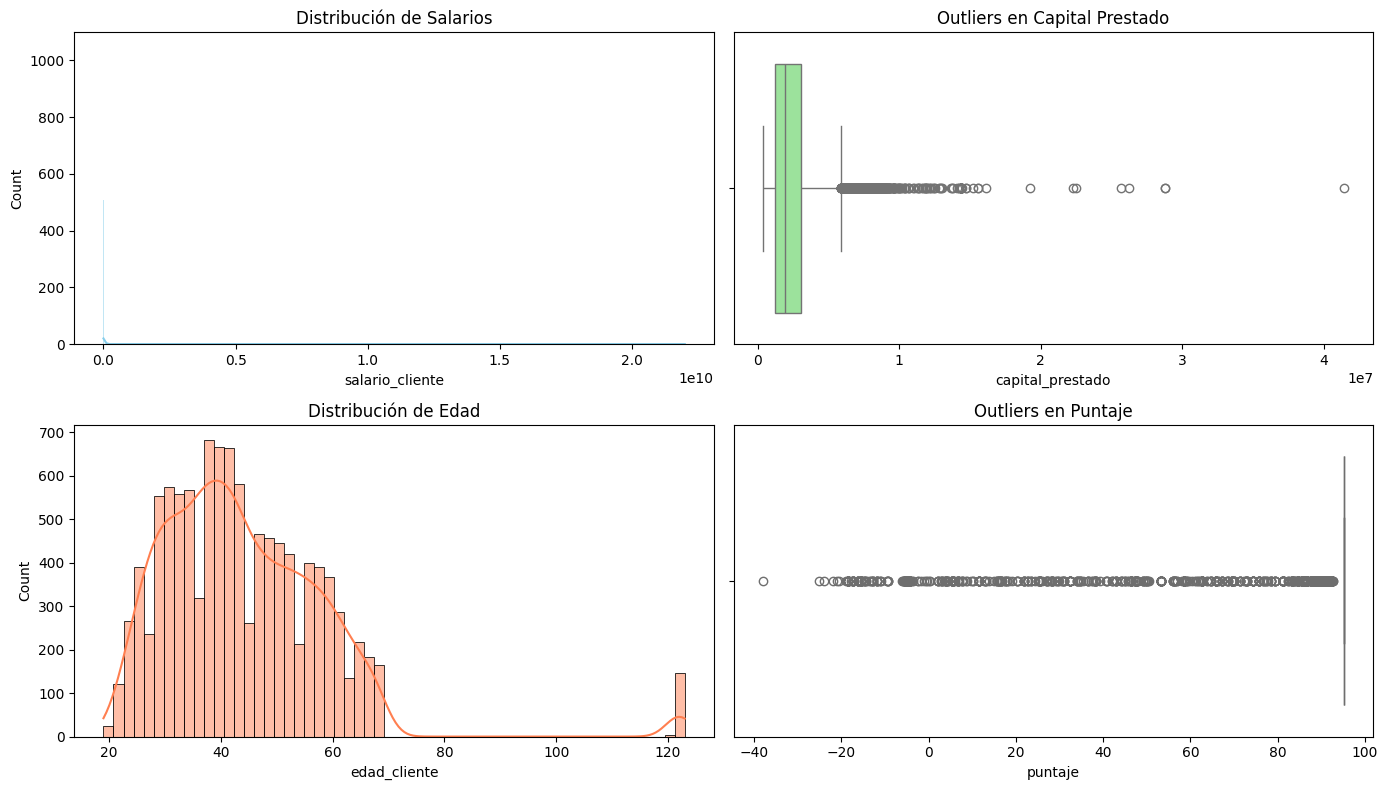

/tmp/ipykernel_1769/3173675713.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='tipo_laboral', data=df, palette='Set2')


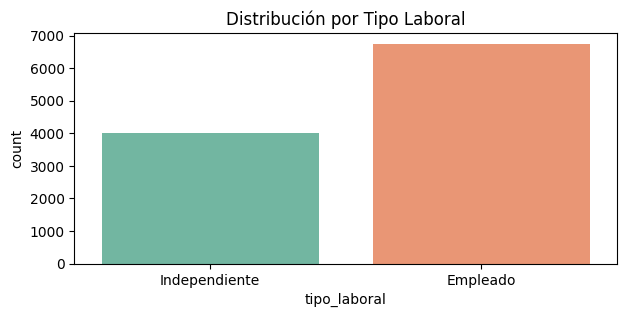

In [ ]:
# 1. Descripción estadística general de variables numéricas
display(df.describe().T)

# 2. Histogramas y Boxplots de variables cuantitativas clave
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Distribución del Salario
sns.histplot(df['salario_cliente'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribución de Salarios')

# Outliers en Capital Prestado
sns.boxplot(x=df['capital_prestado'], ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('Outliers en Capital Prestado')

# Distribución de Edades
sns.histplot(df['edad_cliente'], kde=True, ax=axes[1, 0], color='coral')
axes[1, 0].set_title('Distribución de Edad')

# Outliers en Puntaje
sns.boxplot(x=df['puntaje'], ax=axes[1, 1], color='violet')
axes[1, 1].set_title('Outliers en Puntaje')

plt.tight_layout()
plt.show()

# 3. Frecuencia de variables categóricas
plt.figure(figsize=(7, 3))
sns.countplot(x='tipo_laboral', data=df, palette='Set2')
plt.title('Distribución por Tipo Laboral')
plt.show()

### ⚠️ Hallazgos del Análisis Univariable Inicial (Anomalías y Outliers)

Tras ejecutar el `describe()` y los gráficos univariables iniciales, se detectaron las siguientes inconsistencias severas en los datos:

1. **`salario_cliente` (Error de Carga / Outlier Extremo):**
   * Se registra un valor máximo de **$22,000,000,000** (22 mil millones). Este dato atípico rompe la escala del histograma y comprime el resto de los salarios.
2. **`capital_prestado` (Outlier Extremo):**
   * El 75% de los préstamos es menor o igual a **$3,084,840**, pero existe un valor máximo de **$41,444,152**, lo que aplasta la visualización del diagrama de caja.
3. **`edad_cliente` (Dato Incoherente / Biológicamente Imposible):**
   * Se registra una edad máxima de **123 años**, lo que indica un error de digitación o un valor ficticio/centinela.
4. **`puntaje` (Valores Fuera de Rango):**
   * Presenta valores mínimos de **-38.00**, cuando la métrica de puntaje debe ser positiva.

> **Regla para la exploración visual:** Para poder analizar la forma real de las distribuciones, se graficarán los datos aplicando filtros temporales sobre estas anomalías sin alterar el dataset original.

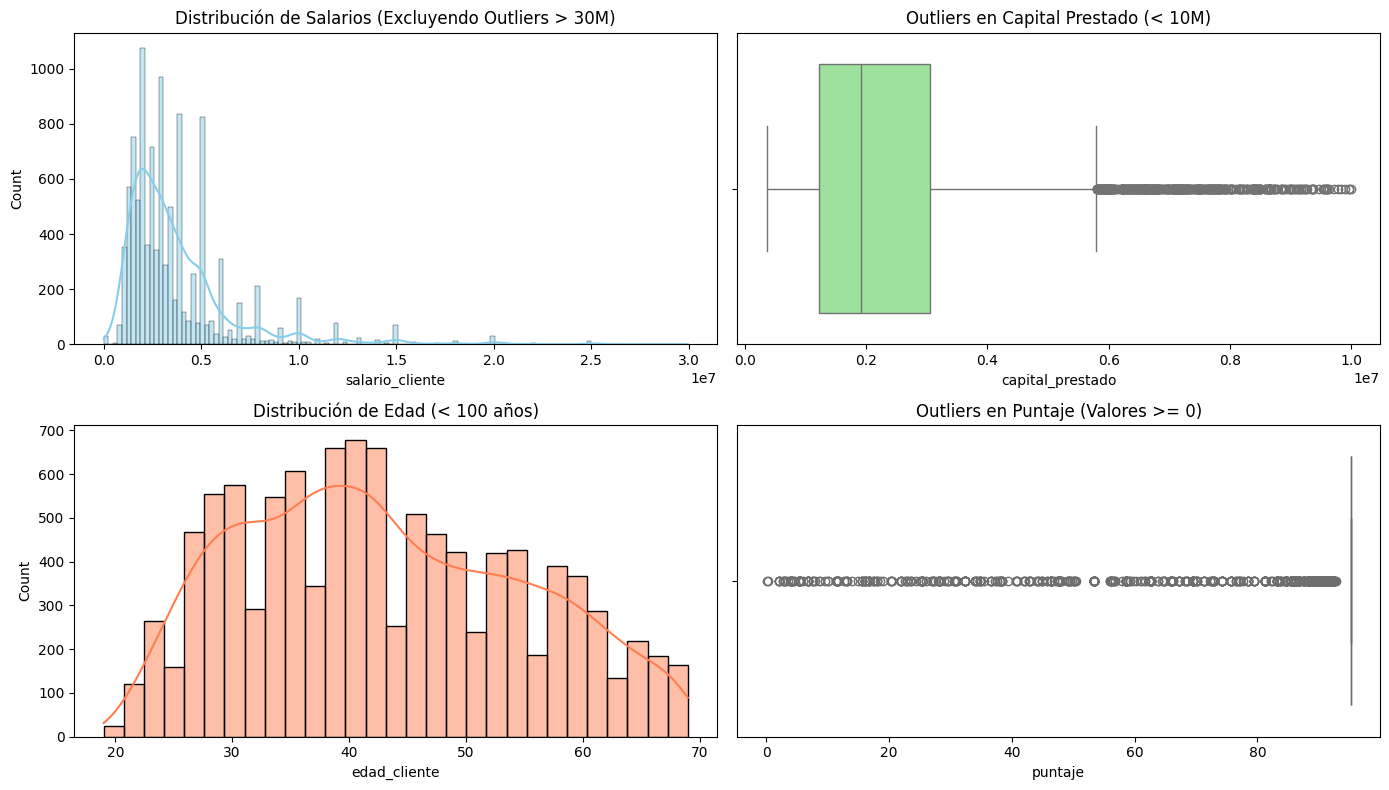

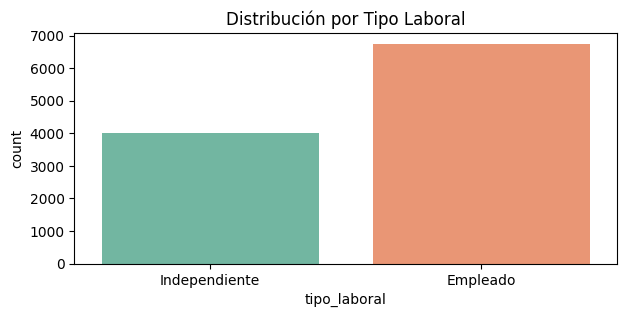

In [ ]:
# Histogramas y Boxplots ajustados visualmente para el Análisis Univariable
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1. Salario: Filtro visual < 30 Millones
salario_valido = df[df['salario_cliente'] < 30000000]['salario_cliente']
sns.histplot(salario_valido, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribución de Salarios (Excluyendo Outliers > 30M)')

# 2. Capital Prestado: Filtro visual < 10 Millones
capital_valido = df[df['capital_prestado'] < 10000000]['capital_prestado']
sns.boxplot(x=capital_valido, ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('Outliers en Capital Prestado (< 10M)')

# 3. Edad: Filtro visual < 100 años
edad_valida = df[df['edad_cliente'] < 100]['edad_cliente']
sns.histplot(edad_valida, kde=True, ax=axes[1, 0], color='coral')
axes[1, 0].set_title('Distribución de Edad (< 100 años)')

# 4. Puntaje: Filtro visual >= 0
puntaje_valido = df[df['puntaje'] >= 0]['puntaje']
sns.boxplot(x=puntaje_valido, ax=axes[1, 1], color='violet')
axes[1, 1].set_title('Outliers en Puntaje (Valores >= 0)')

plt.tight_layout()
plt.show()

# 5. Frecuencia de tipo laboral (corregido para evitar la advertencia de Seaborn)
plt.figure(figsize=(7, 3))
sns.countplot(x='tipo_laboral', hue='tipo_laboral', data=df, palette='Set2', legend=False)
plt.title('Distribución por Tipo Laboral')
plt.show()

### 4 ANALISIS BIVARIABLE (Relacionado con Pago_atiempo)

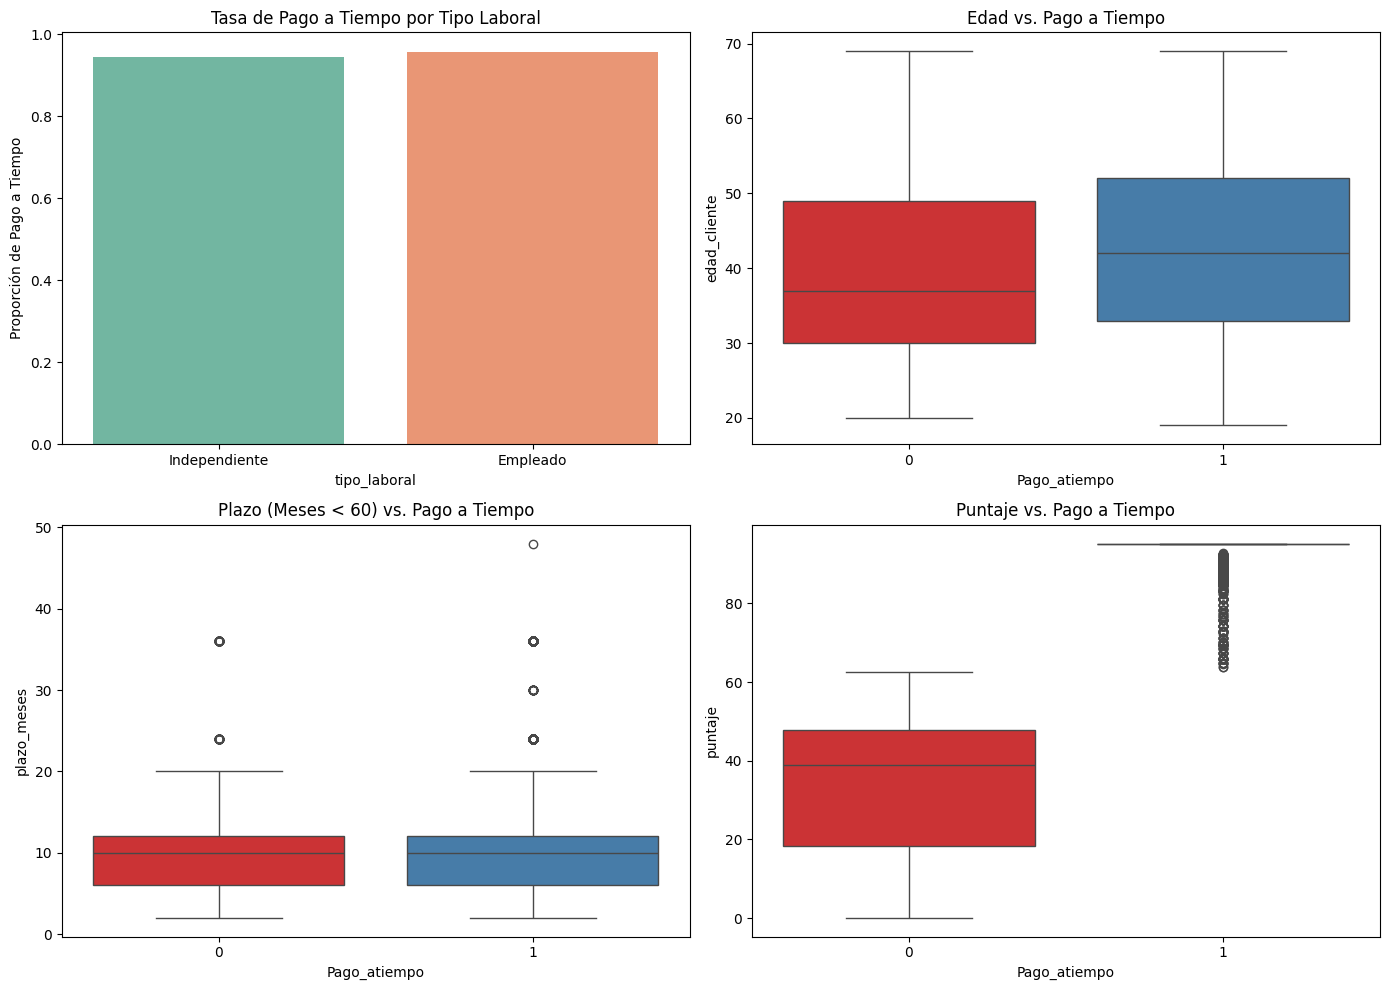

--- Tasa de cumplimiento exacto por Tipo Laboral (%) ---
tipo_laboral
Empleado         95.706248
Independiente    94.487403
Name: Pago_atiempo, dtype: float64


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Tasa de cumplimiento por Tipo Laboral (Se asigna 'hue' para evitar warnings)
sns.barplot(x='tipo_laboral', y='Pago_atiempo', hue='tipo_laboral', data=df, ax=axes[0, 0], palette='Set2', errorbar=None, legend=False)
axes[0, 0].set_title('Tasa de Pago a Tiempo por Tipo Laboral')
axes[0, 0].set_ylabel('Proporción de Pago a Tiempo')

# 2. Distribución de Edad por Comportamiento de Pago (Filtro edad < 100)
sns.boxplot(x='Pago_atiempo', y='edad_cliente', hue='Pago_atiempo', data=df[df['edad_cliente'] < 100], ax=axes[0, 1], palette='Set1', legend=False)
axes[0, 1].set_title('Edad vs. Pago a Tiempo')

# 3. Plazo en Meses vs. Pago a Tiempo (Filtro visual sin outlier de 90 meses)
sns.boxplot(x='Pago_atiempo', y='plazo_meses', hue='Pago_atiempo', data=df[df['plazo_meses'] < 60], ax=axes[1, 0], palette='Set1', legend=False)
axes[1, 0].set_title('Plazo (Meses < 60) vs. Pago a Tiempo')

# 4. Puntaje Crediticio vs. Pago a Tiempo (Filtro puntaje >= 0)
sns.boxplot(x='Pago_atiempo', y='puntaje', hue='Pago_atiempo', data=df[df['puntaje'] >= 0], ax=axes[1, 1], palette='Set1', legend=False)
axes[1, 1].set_title('Puntaje vs. Pago a Tiempo')

plt.tight_layout()
plt.show()

# Tabla cruzada de porcentajes de pago por tipo laboral
print("--- Tasa de cumplimiento exacto por Tipo Laboral (%) ---")
print(df.groupby('tipo_laboral')['Pago_atiempo'].mean() * 100)

### 📊 Conclusiones del Análisis Bivariable

1. **Tipo Laboral:**
   * Los empleados presentan una tasa de pago a tiempo levemente mayor (**95.71%**) frente a los independientes (**94.49%**). La estabilidad del ingreso influye en el cumplimiento.
2. **Edad vs. Pago a Tiempo:**
   * La mediana de edad de los clientes que pagan a tiempo es ligeramente superior a la de quienes entran en mora, indicando que a mayor edad suele existir un perfil de menor riesgo.
3. **Plazo en Meses:**
   * La gran mayoría de los créditos se concentran en plazos cortos (6 a 12 meses). Se identificó un outlier extremo de **90 meses** que se acotó en la visualización para mejorar la lectura de la distribución.
4. **Puntaje Crediticio:**
   * Muestra un poder de separación claro: los clientes con comportamiento de pago a tiempo (`Pago_atiempo = 1`) concentran puntajes significativamente más altos e homogéneos en comparación con los clientes en mora.

### 5. Análisis Multivariable (Matriz de Correlación)

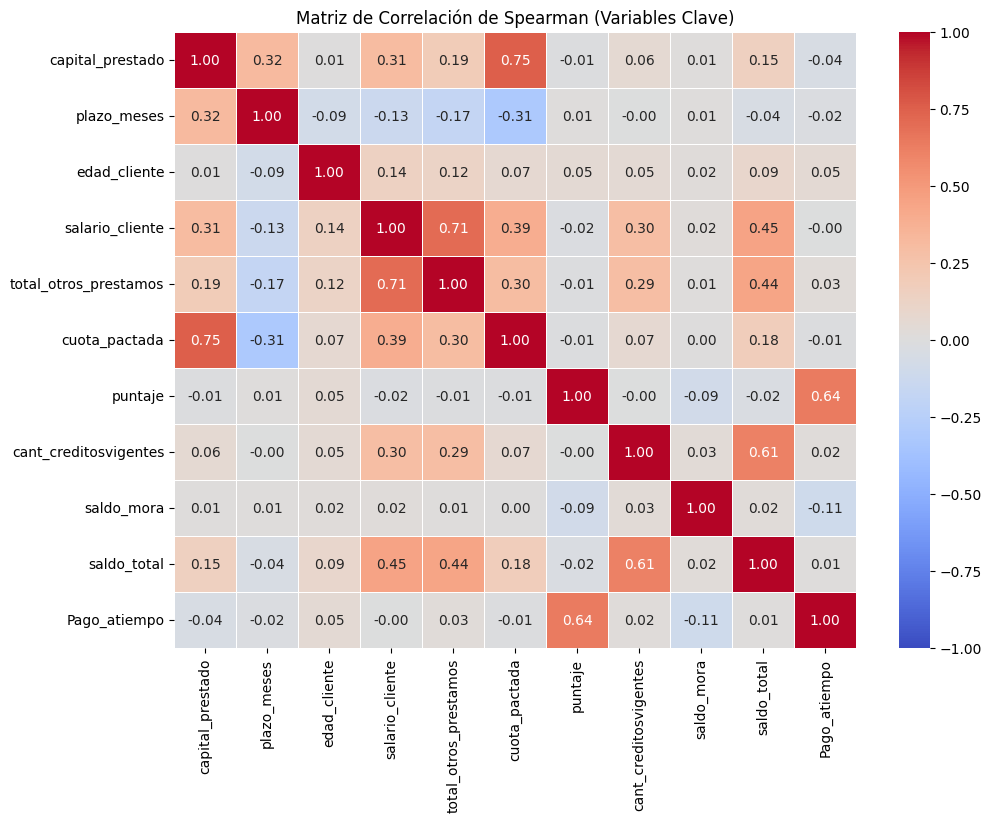

In [ ]:
cols_numericas = [
    'capital_prestado', 'plazo_meses', 'edad_cliente', 'salario_cliente',
    'total_otros_prestamos', 'cuota_pactada', 'puntaje',
    'cant_creditosvigentes', 'saldo_mora', 'saldo_total', 'Pago_atiempo'
]

# Matriz de Spearman (resistente a outliers)
corr = df[cols_numericas].corr(method='spearman')

# Visualización del Heatmap
plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlación de Spearman (Variables Clave)')
plt.show()

#### 🔝 Top de Variables con Mayor Influencia y Relación

1. **`puntaje` $\rightarrow$ `Pago_atiempo` (0.64):**
   * Es la correlación positiva más fuerte del dataset. Confirma que el scoring es la variable con mayor capacidad discriminativa para predecir si el cliente pagará a tiempo.

2. **`salario_cliente` $\leftrightarrow$ `total_otros_prestamos` (0.71):**
   * Fuerte relación positiva. A mayor nivel de ingresos, mayor es la capacidad y el volumen de endeudamiento externo que asume el cliente.

3. **`cuota_pactada` $\leftrightarrow$ `capital_prestado` (0.75):**
   * Correlación directa esperada por regla de negocio: montos desembolsados más altos imponen valores de cuotas mensuales proporcionalmente mayores.

4. **`saldo_total` $\leftrightarrow$ `cant_creditosvigentes` (0.61):**
   * Relación lógica donde tener un mayor número de productos financieros activos incrementa el volumen total de saldo adeudado.

5. **`saldo_mora` $\rightarrow$ `Pago_atiempo` (-0.11):**
   * Correlación negativa: la presencia de saldo en mora reduce directamente la probabilidad de cumplir a tiempo con el pago actual.

## 📌 Resumen de Reglas de Negocio para la Fase de Preprocesamiento

Finalizado el Análisis Exploratorio de Datos (EDA), se establecen las reglas técnicas a aplicar en la etapa de preparación de datos:

1. **Tratamiento de Nulos:**
   * Imputar en `0.0` los saldos nulos (`saldo_mora`, `saldo_total`, `saldo_principal`, etc.) asumiendo ausencia de deuda activa.
   * Definir estrategia para variables de DataCrédito (~27% de faltantes).

2. **Depuración de Errores e Inconsistencias:**
   * Filtrar o eliminar registros con `edad_cliente > 100`.
   * Convertir a `NaN` los valores negativos en `puntaje` (`puntaje < 0`) para su posterior imputación.

3. **Manejo de Outliers:**
   * Recortar por IQR o aplicar transformación logarítmica ($\log(x+1)$) en `salario_cliente` y `capital_prestado` para controlar el sesgo de los valores extremos aberrantes.

4. **Codificación (Encoding):**
   * Aplicar *One-Hot Encoding* a las variables categóricas `tipo_laboral` y `tipo_credito`.